### Instalations

In [1]:
pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install pytorch-lightning

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import sys
!{sys.executable} -m pip install -U tensorboardX


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [10]:
import os
import random
import requests

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
import pytorch_lightning as pl

from torch.optim import AdamW
from torch.utils.data import DataLoader, Subset, Sampler

from torchvision import models, datasets, transforms
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

from transformers import AutoImageProcessor, AutoModelForImageClassification

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from imblearn.ensemble import BalancedRandomForestClassifier
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

### Dataset

In [11]:
#Dataset
pat = r"C:\Users\bruno\Documents\Transfer learning\png_224" #CHANGE!

#Output dir
OUT_DIR = r"C:\Users\bruno\Documents\Transfer learning"  #CHANGE!
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

#Tabelas
TABLE_MULTI_PATH  = os.path.join(OUT_DIR, "ALL_MorphoSPLUS_GalfitM_output_splus.csv")  
LABELS_TABLE_PATH = os.path.join(OUT_DIR, "tabela_filtrada.csv")                       

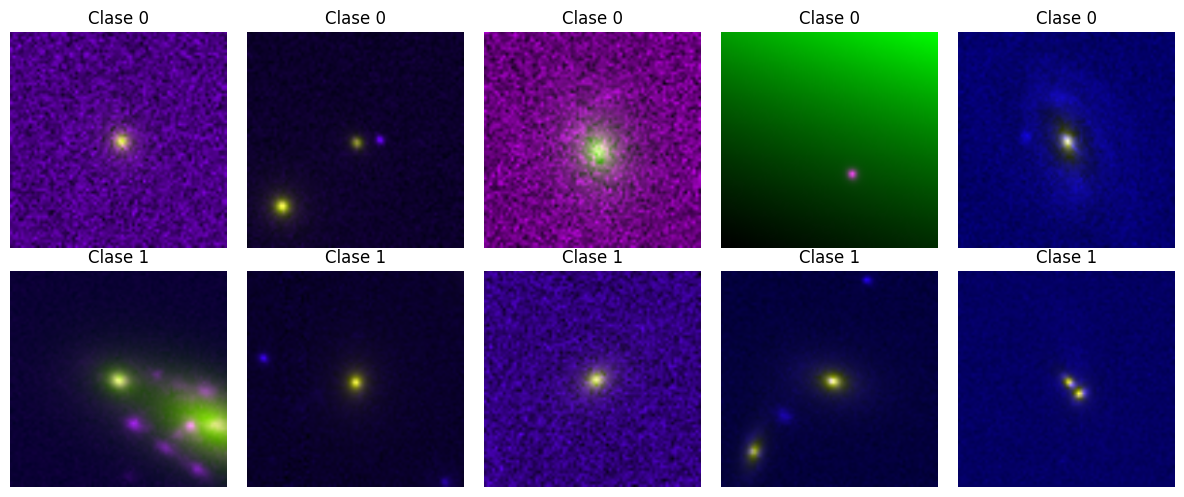

In [12]:

train_dir = f"{pat}/train"

# 5 imágenes por clase
images_class0 = random.sample(os.listdir(os.path.join(train_dir, "clase0")), 5)
images_class1 = random.sample(os.listdir(os.path.join(train_dir, "clase1")), 5)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Fila 0 -> clase 0
for col in range(5):
    img_path = os.path.join(train_dir, "clase0", images_class0[col])
    img = Image.open(img_path)
    axes[0, col].imshow(img)
    axes[0, col].set_title("Clase 0")
    axes[0, col].axis("off")

# Fila 1 -> clase 1
for col in range(5):
    img_path = os.path.join(train_dir, "clase1", images_class1[col])
    img = Image.open(img_path)
    axes[1, col].imshow(img)
    axes[1, col].set_title("Clase 1")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Load a transformer trained in ImageNet-1k

In [13]:

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/hub/parrots.png"
image = Image.open(requests.get(url, stream=True).raw)


model_name = "facebook/deit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)


# -------- PRINT IMAGE --------
print("type:", type(image))

if isinstance(image, np.ndarray):
    print("shape:", image.shape)
    print("ndim:", image.ndim)
    if image.ndim == 2:
        image = np.stack([image]*3, axis=-1)
    image = Image.fromarray(image)

print("PIL mode before:", image.mode)

image = image.convert("RGB")

print("PIL mode after:", image.mode)
print("size:", image.size)

# -------- INFERENCIA --------
with torch.no_grad():
    inputs = processor(images=image, return_tensors="pt")
    outputs = model(**inputs)
    logits = outputs.logits

predicted_class_id = logits.argmax(-1).item()

print("Clase predicha:", model.config.id2label[predicted_class_id])

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

type: <class 'PIL.PngImagePlugin.PngImageFile'>
PIL mode before: L
PIL mode after: RGB
size: (768, 512)
Clase predicha: macaw


# Descongelar LayerNorm + últimos bloques (más estable)

In [14]:
# ============================================
# Descongelar classifier + últimos 2 bloques (ViT HF)
# ============================================


# 1️⃣ Cambiar a 1 logit
model.config.num_labels = 1
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 1)

# 2️⃣ Congelar TODO el modelo
for param in model.parameters():
    param.requires_grad = False

# 3️⃣ Descongelar últimos 2 bloques Transformer
# (compatible con ViT y DeiT en HuggingFace)

for block in model.vit.encoder.layer[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# 4️⃣ Descongelar LayerNorm final
for param in model.vit.layernorm.parameters():
    param.requires_grad = True

# 5️⃣ Descongelar classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# ============================================
# Verificación
# ============================================

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,}")
print(f"Total params: {total:,}")
print(f"Trainable %: {100 * trainable / total:.4f}%")

Trainable params: 14,178,049
Total params: 85,799,425
Trainable %: 16.5246%


In [15]:
# Verificar qué se está entrenando
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,}")
print(f"Total params: {total:,}")
print(f"% trainable: {100*trainable/total:.2f}%")

Trainable params: 14,178,049
Total params: 85,799,425
% trainable: 16.52%


## Augmentation and dataloader

In [16]:
# ============================================
# BalancedBatchSampler
# Genera batches SIEMPRE balanceados 50/50
# ============================================

class BalancedBatchSampler(Sampler):
    def __init__(self, dataset, batch_size):
        self.dataset = dataset
        self.batch_size = batch_size
        self.targets = torch.tensor(dataset.targets)

        assert batch_size % 2 == 0, "batch_size debe ser par"

        self.class0_idx = torch.where(self.targets == 0)[0].tolist()
        self.class1_idx = torch.where(self.targets == 1)[0].tolist()

        self.min_class_size = min(len(self.class0_idx), len(self.class1_idx))
        self.num_batches = self.min_class_size // (batch_size // 2)

    def __iter__(self):
        random.shuffle(self.class0_idx)
        random.shuffle(self.class1_idx)

        for i in range(self.num_batches):
            batch0 = self.class0_idx[i*(self.batch_size//2):(i+1)*(self.batch_size//2)]
            batch1 = self.class1_idx[i*(self.batch_size//2):(i+1)*(self.batch_size//2)]

            batch = batch0 + batch1
            random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches


# ============================================
# Transforms
# ============================================

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomChoice([
        transforms.RandomRotation((0, 0)),
        transforms.RandomRotation((90, 90)),
        transforms.RandomRotation((180, 180)),
        transforms.RandomRotation((270, 270)),
    ]),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# ============================================
# Datasets
# ============================================

train_dataset = datasets.ImageFolder(
    root=f"{pat}/train",
    transform=train_transforms)

val_dataset   = datasets.ImageFolder(
    root=f"{pat}/val",
    transform=eval_transforms)

test_dataset  = datasets.ImageFolder(
    root=f"{pat}/test",
    transform=eval_transforms)

# ============================================
# DataLoaders con batches balanceados
# ============================================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_sampler=BalancedBatchSampler(train_dataset, batch_size),
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

print("Clases:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Clases: ['clase0', 'clase1']
Train size: 4283
Val size: 1049
Test size: 1010


In [17]:
class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        path = self.samples[index][0]
        return img, label, path

test_dataset_paths = ImageFolderWithPaths(
    root=f"{pat}/test",
    transform=eval_transforms
)

test_loader_paths = DataLoader(
    test_dataset_paths,
    batch_size=32, 
    shuffle=False,
    num_workers=0
)

print("Classes (paths):", test_dataset_paths.classes)
print("Test size (paths):", len(test_dataset_paths))

Classes (paths): ['clase0', 'clase1']
Test size (paths): 1010


Seed set to 42


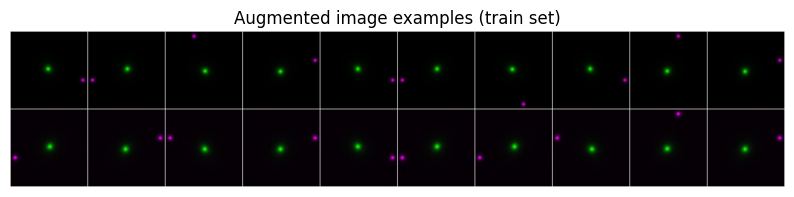

In [18]:


pl.seed_everything(42)

NUM_IMAGES = 2  # número de imágenes base

# Dataset con transforms de TRAIN (augmentations activos)
aug_dataset = datasets.ImageFolder(
    root=f"{pat}/train",
    transform=train_transforms  # <-- usa el transform con augmentations
)

# Tomar N imágenes y generar múltiples vistas (ej. 6 augmentations por imagen)
imgs = torch.stack(
    [aug_dataset[idx][0] for idx in range(NUM_IMAGES) for _ in range(10)],
    dim=0
)

img_grid = torchvision.utils.make_grid(
    imgs,
    nrow=10,
    normalize=True,
    pad_value=0.9
)

img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(10, 5))
plt.title("Augmented image examples (train set)")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

In [19]:
# =========================================================
# BCE + Weight Decay + F1 robusto (sin errores de acumulación)
# =========================================================

import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.optim import AdamW
from torchmetrics.classification import BinaryF1Score


class LitViT(pl.LightningModule):
    def __init__(self, model, lr=3e-5, weight_decay=0.01):
        super().__init__()
        self.model = model
        self.save_hyperparameters(ignore=["model"])

        self.criterion = nn.BCEWithLogitsLoss()

        # acumulación correcta por epoch
        self.train_f1 = BinaryF1Score()
        self.val_f1 = BinaryF1Score()

    def forward(self, x):
        return self.model(pixel_values=x).logits.squeeze(1)

    def training_step(self, batch, batch_idx):
        images, labels = batch

        logits = self(images)
        loss = self.criterion(logits, labels.float())

        probs = torch.sigmoid(logits)
        self.train_f1.update(probs, labels)

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def on_train_epoch_end(self):
        f1 = self.train_f1.compute()
        self.log("train_f1", f1, prog_bar=True)
        self.train_f1.reset()

    def validation_step(self, batch, batch_idx):
        images, labels = batch

        logits = self(images)
        loss = self.criterion(logits, labels.float())

        probs = torch.sigmoid(logits)
        self.val_f1.update(probs, labels)

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def on_validation_epoch_end(self):
        f1 = self.val_f1.compute()
        self.log("val_f1", f1, prog_bar=True)
        self.val_f1.reset()

    def configure_optimizers(self):
        return AdamW(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay  # ✅ agregado
        )



In [20]:
import sys
!{sys.executable} -m pip install -U tensorboard


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# =========================================================
# Entrenamiento
# =========================================================

lit_vit = LitViT(model)

ckpt_vit = ModelCheckpoint(
    dirpath= r"C:\Users\bruno\Documents\Transfer learning/checkpoints", #CHANGE!
    filename="vit-{epoch:02d}-{val_f1:.4f}",
    monitor="val_f1",
    mode="max",
    save_top_k=1
)

early_stop = EarlyStopping(
    monitor="val_f1",
    mode="max",
    patience=10,
    min_delta=1e-4,
    verbose=True
)

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10,
    logger=pl.loggers.TensorBoardLogger("tb_logs"),
    callbacks=[ckpt_vit, early_stop]
)


trainer.fit(lit_vit, train_loader, val_loader)
print("Best ViT ckpt:", ckpt_vit.best_model_path)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\bruno\Documents\Transfer learning\checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ViTForImageClassification │ 85.8 M │ eval  │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss         │      0 │ train │     0 │
│ 2 │ train_f1  │ BinaryF1Score             │      0 │ train │     0 │
│ 3 │ val_f1    │ BinaryF1Score             │      0 │ train │     0 │
└───┴───────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 14.2 M                                                                                           
Non-trainable params: 71.6 M                                                                                       
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 4                                                                                           
Modules in eval mode: 213                                                                                          
Total FLOPs: 0

Output()

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker 
initialization.

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader 
worker initialization.

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:534: 
Found 213 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If
this is intentional, you can ignore this warning.

Metric val_f1 improved. New best score: 0.332
Metric val_f1 improved by 0.039 >= min_delta = 0.0001. New best score: 0.371
Metric val_f1 improved by 0.005 >= min_delta = 0.0001. New best score: 0.377
Metric val_f1 improved by 0.007 >= min_delta = 0.0001. New best score: 0.384
Metric val_f1 improved by 0.038 >= min_delta = 0.0001. New best score: 0.422
Metric val_f1 improved by 0.010 >= min_delta = 0.0001. New best score: 0.431
`Trainer.fit` stopped: `max_epochs=10` reached.


Best ViT ckpt: C:\Users\bruno\Documents\Transfer learning\checkpoints\vit-epoch=09-val_f1=0.4315.ckpt



ViT TEST:
F1: 0.40703517587939697


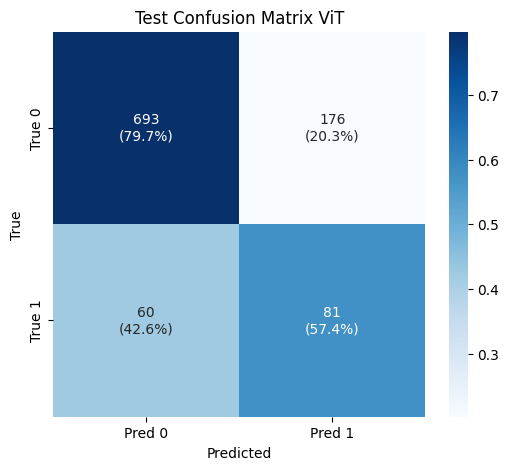

In [22]:
lit_vit.eval()
all_preds = []
all_targets = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(lit_vit.device)
        labels = labels.to(lit_vit.device)

        logits = lit_vit(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()

        all_preds.append(preds.cpu())
        all_targets.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

vit_f1 = f1_score(all_targets, all_preds, zero_division=0)
print("\nViT TEST:")
print("F1:", vit_f1)

cm = confusion_matrix(all_targets, all_preds)

# Normalización por fila
cm_percent = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

# Crear etiquetas combinadas
labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_percent[i, j] * 100
        labels[i, j] = f"{count}\n({percent:.1f}%)"

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix ViT")
plt.show()

## ResNet

In [23]:
# =========================================================
# ResNet18
# Descongelar último bloque (layer4) + FC
# Similar a descongelar últimos bloques en ViT
# =========================================================

import torch
import torch.nn as nn
import pytorch_lightning as pl
import torchvision.models as models
from torch.optim import AdamW
from torchmetrics.classification import BinaryF1Score


# =========================================================
# 1️⃣ Modelo base
# =========================================================

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelar todo
for param in resnet.parameters():
    param.requires_grad = False

# Cambiar FC → 1 logit
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 1)

# Descongelar último bloque (layer4)
for param in resnet.layer4.parameters():
    param.requires_grad = True

# Descongelar FC
for param in resnet.fc.parameters():
    param.requires_grad = True


# =========================================================
# 2️⃣ Lightning Module
# =========================================================

class LitResNet(pl.LightningModule):
    def __init__(self, model, lr=1e-4, weight_decay=0.01):
        super().__init__()
        self.model = model
        self.save_hyperparameters(ignore=["model"])

        self.criterion = nn.BCEWithLogitsLoss()

        self.train_f1 = BinaryF1Score()
        self.val_f1 = BinaryF1Score()

    def forward(self, x):
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        images, labels = batch

        logits = self(images)
        loss = self.criterion(logits, labels.float())

        probs = torch.sigmoid(logits)
        self.train_f1.update(probs, labels)

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        f1 = self.train_f1.compute()
        self.log("train_f1", f1, prog_bar=True)
        self.train_f1.reset()

    def validation_step(self, batch, batch_idx):
        images, labels = batch

        logits = self(images)
        loss = self.criterion(logits, labels.float())

        probs = torch.sigmoid(logits)
        self.val_f1.update(probs, labels)

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def on_validation_epoch_end(self):
        f1 = self.val_f1.compute()
        self.log("val_f1", f1, prog_bar=True)
        self.val_f1.reset()

    def configure_optimizers(self):
        # entrenar solo layer4 + fc
        params = list(self.model.layer4.parameters()) + list(self.model.fc.parameters())

        return AdamW(
            params,
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay
        )


# =========================================================
# 3️⃣ Entrenamiento
# =========================================================

lit_resnet = LitResNet(resnet)

ckpt_resnet = ModelCheckpoint(
    dirpath= r"C:\Users\bruno\Documents\Transfer learning\checkpoints", #CHANGE!
    filename="vit-{epoch:02d}-{val_f1:.4f}",
    monitor="val_f1",
    mode="max",
    save_top_k=1
)

early_stop = EarlyStopping(
    monitor="val_f1",
    mode="max",
    patience=10,
    min_delta=1e-4, 
    verbose=True
)

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10,
    logger=pl.loggers.TensorBoardLogger("tb_logs"),
    callbacks=[ckpt_resnet, early_stop]
)

trainer.fit(lit_resnet, train_loader, val_loader)
print("Best ResNet ckpt:", ckpt_resnet.best_model_path)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\bruno\Documents\Transfer learning\checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet            │ 11.2 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_f1  │ BinaryF1Score     │      0 │ train │     0 │
│ 3 │ val_f1    │ BinaryF1Score     │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 8.4 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker 
initialization.

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader 
worker initialization.

Metric val_f1 improved. New best score: 0.358
Metric val_f1 improved by 0.022 >= min_delta = 0.0001. New best score: 0.380
Metric val_f1 improved by 0.011 >= min_delta = 0.0001. New best score: 0.391
Metric val_f1 improved by 0.009 >= min_delta = 0.0001. New best score: 0.400
Metric val_f1 improved by 0.042 >= min_delta = 0.0001. New best score: 0.442
Metric val_f1 improved by 0.002 >= min_delta = 0.0001. New best score: 0.444
Metric val_f1 improved by 0.006 >= min_delta = 0.0001. New best score: 0.450
Metric val_f1 improved by 0.062 >= min_delta = 0.0001. New best score: 0.512
`Trainer.fit` stopped: `max_epochs=10` reached.


Best ResNet ckpt: C:\Users\bruno\Documents\Transfer learning\checkpoints\vit-epoch=08-val_f1=0.5120-v1.ckpt



RESNET TEST:
F1: 0.41935483870967744


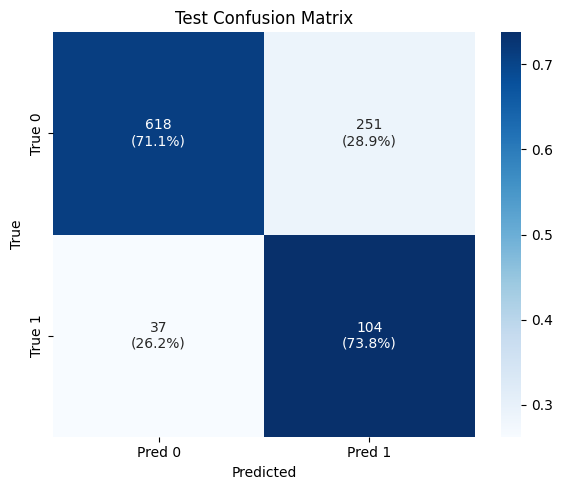

In [24]:
# =========================================================
# Confusion Matrix robusta (funciona para ResNet BCE 1-logit)
# =========================================================


lit_resnet.eval()

device = lit_resnet.device
all_preds = []
all_targets = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = lit_resnet(images)              # [B]
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()

        all_preds.append(preds.cpu())
        all_targets.append(labels.cpu())

# Concatenar correctamente
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

resnet_f1 = f1_score(all_targets, all_preds, zero_division=0)
print("\nRESNET TEST:")
print("F1:", resnet_f1)

# Matriz absoluta
cm = confusion_matrix(all_targets, all_preds)

# Evitar división por cero si una clase no aparece
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1

cm_percent = cm.astype(np.float32) / row_sums

# Etiquetas combinadas
labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_percent[i, j] * 100
        labels[i, j] = f"{count}\n({percent:.1f}%)"

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
ls

 O volume na unidade C nÆo tem nome.
 O N£mero de S‚rie do Volume ‚ C0AF-C978

 Pasta de C:\Users\bruno\Documents\Transfer learning

04/03/2026  20:49    <DIR>          .
28/02/2026  09:34    <DIR>          ..
01/03/2026  20:42    <DIR>          .ipynb_checkpoints
02/03/2026  07:54         1.297.937 2. (50) example_pytorch_Transferlearning_CNN_vs_Transformer-Copy1.ipynb
04/03/2026  20:49           956.906 3. (10) example_pytorch_Transferlearning_CNN_vs_Transformer.ipynb
28/02/2026  09:34         2.751.249 ALL_MorphoSPLUS_GalfitM_output_splus.csv
28/02/2026  09:34         1.387.285 analise_exploratoria_tabela copy.ipynb
04/03/2026  20:54    <DIR>          checkpoints
28/02/2026  09:34           262.877 example_pytorch_Transferlearning_CNN_vs_Transformer.ipynb
28/02/2026  09:34    <DIR>          png_224
28/02/2026  09:34         1.385.650 random-forest.ipynb
28/02/2026  09:34           102.330 tabela_filtrada.csv
28/02/2026  10:25    <DIR>          tb_logs
               7 arquivo(s)    

## Balanced Random forest

In [26]:
# Custom ImageFolder that also returns the file path
class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        path = self.samples[index][0]
        return img, label, path

def make_loader_with_paths(root, transform, batch_size=32, num_workers=0):
    ds = ImageFolderWithPaths(root=root, transform=transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return dl

train_loader_paths = make_loader_with_paths(f"{pat}/train", eval_transforms)
val_loader_paths   = make_loader_with_paths(f"{pat}/val",   eval_transforms)
test_loader_paths  = make_loader_with_paths(f"{pat}/test",  eval_transforms)

#Extract object id
OID_RE = re.compile(r"(DR\d+_\d+_STRIPE82-\d{4}_\d{7})")

def object_id_from_path(p: str) -> str:
    name = os.path.basename(p)
    m = OID_RE.search(name)
    if m:
        return m.group(1)
    name = re.sub(r"\.[^.]+$", "", name)
    return str(name).strip().rstrip(".")

def ids_from_loader(dl) -> set[str]:
    ids = set()
    for _, _, paths in dl:
        for p in paths:
            ids.add(object_id_from_path(p))
    return ids

train_ids = ids_from_loader(train_loader_paths)
val_ids   = ids_from_loader(val_loader_paths)
test_ids  = ids_from_loader(test_loader_paths)

# Probs
import torch
import pandas as pd

def predict_probs_with_paths(lit_model, dl):
    lit_model.eval()
    device = getattr(lit_model, "device", None)
    if device is None:
        device = next(lit_model.parameters()).device

    rows = []

    with torch.inference_mode():
        for images, labels, paths in dl:
            images = images.to(device, non_blocking=True)

            logits = lit_model(images)

            if isinstance(logits, (tuple, list)):
                logits = logits[0]

            #Calcula prob_1 dependendo do formato
            if logits.ndim == 1:
                # (B,) -> binário
                prob_1 = torch.sigmoid(logits)
            elif logits.ndim == 2 and logits.shape[1] == 1:
                # (B,1) -> binário
                prob_1 = torch.sigmoid(logits.squeeze(1))
            elif logits.ndim == 2 and logits.shape[1] >= 2:
                # (B,2) (ou mais) -> multiclass, pega classe 1
                prob_1 = torch.softmax(logits, dim=1)[:, 1]
            else:
                raise ValueError(f"Formato inesperado de logits: shape={tuple(logits.shape)}")

            prob_1 = prob_1.detach().cpu().numpy()
            labels_np = labels.detach().cpu().numpy()

            #paths pode vir como lista/tuple de strings ou tensor de strings (depende do collate)
            for y, p, pr in zip(labels_np, paths, prob_1):
                p_str = str(p)
                oid = object_id_from_path(p_str)
                rows.append({
                    "object_id": oid,
                    "path": p_str,
                    "y_true": int(y),
                    "prob_1": float(pr),
                })

    return pd.DataFrame(rows)
    
df_vit_train = predict_probs_with_paths(lit_vit, train_loader_paths).rename(columns={"prob_1": "vit_prob_1"})
df_vit_val   = predict_probs_with_paths(lit_vit, val_loader_paths).rename(columns={"prob_1": "vit_prob_1"})
df_vit_test  = predict_probs_with_paths(lit_vit, test_loader_paths).rename(columns={"prob_1": "vit_prob_1"})

df_res_train = predict_probs_with_paths(lit_resnet, train_loader_paths).rename(columns={"prob_1": "resnet_prob_1"})
df_res_val   = predict_probs_with_paths(lit_resnet, val_loader_paths).rename(columns={"prob_1": "resnet_prob_1"})
df_res_test  = predict_probs_with_paths(lit_resnet, test_loader_paths).rename(columns={"prob_1": "resnet_prob_1"})

df_vit_train_agg = df_vit_train.groupby("object_id", as_index=False)["vit_prob_1"].mean()
df_vit_val_agg   = df_vit_val.groupby("object_id",   as_index=False)["vit_prob_1"].mean()
df_vit_test_agg  = df_vit_test.groupby("object_id",  as_index=False)["vit_prob_1"].mean()

df_res_train_agg = df_res_train.groupby("object_id", as_index=False)["resnet_prob_1"].mean()
df_res_val_agg   = df_res_val.groupby("object_id",   as_index=False)["resnet_prob_1"].mean()
df_res_test_agg  = df_res_test.groupby("object_id",  as_index=False)["resnet_prob_1"].mean()

print("df_vit_train_agg:", df_vit_train_agg.shape, "df_res_train_agg:", df_res_train_agg.shape)
print(df_vit_train_agg.head())
print(df_res_train_agg.head())

df_vit_train_agg: (1429, 2) df_res_train_agg: (1429, 2)
                     object_id  vit_prob_1
0  DR4_3_STRIPE82-0001_0006417    0.093026
1  DR4_3_STRIPE82-0001_0007728    0.440911
2  DR4_3_STRIPE82-0001_0007918    0.114692
3  DR4_3_STRIPE82-0001_0008235    0.210342
4  DR4_3_STRIPE82-0002_0001343    0.082442
                     object_id  resnet_prob_1
0  DR4_3_STRIPE82-0001_0006417       0.087302
1  DR4_3_STRIPE82-0001_0007728       0.184158
2  DR4_3_STRIPE82-0001_0007918       0.060725
3  DR4_3_STRIPE82-0001_0008235       0.011158
4  DR4_3_STRIPE82-0002_0001343       0.047894


In [27]:
SEED = 42

#Read table and build df_table
df_tab = pd.read_csv(TABLE_MULTI_PATH, low_memory=False)
df_labels = pd.read_csv(LABELS_TABLE_PATH, low_memory=False)

df_tab["ID_1"] = df_tab["ID_1"].astype(str)
df_labels["ID"] = df_labels["ID"].astype(str)

# 0 = good, 1 = bad
df_labels["label"] = df_labels["type"].apply(lambda x: 0 if int(x) == 0 else 1).astype(int)

df_table = (
    df_tab.merge(
        df_labels[["ID", "label"]],
        left_on="ID_1",
        right_on="ID",
        how="inner"
    )
    .drop(columns=["ID"])
)

df_table["label"] = df_table["label"].astype(int)

print("\nAfter merge:", df_table.shape)
print(df_table["label"].value_counts())

#Clean df
text_cols = ["source_folder", "source_file", "ID_1", "Field_ID", "Dir_", "Field"]

def plot_cm_percent(cm, title):
    cm = np.array(cm, dtype=int)

    row_sums = cm.sum(axis=1, keepdims=True).astype(np.float32)
    row_sums[row_sums == 0] = 1.0
    cm_percent = cm.astype(np.float32) / row_sums

    labels = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            percent = cm_percent[i, j] * 100.0
            labels[i, j] = f"{count}\n({percent:.1f}%)"

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_percent,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for col in df_table.columns:
    if col in text_cols or col == "label":
        continue

    s = df_table[col].astype(str)
    s = s.str.replace("*", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    s = s.str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    df_table[col] = pd.to_numeric(s, errors="coerce")

numeric_cols = df_table.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("label")


After merge: (1442, 219)
label
0    1251
1     191
Name: count, dtype: int64


In [28]:
if "object_id" not in df_table.columns:
    if "ID_1" not in df_table.columns:
        raise KeyError("df_table não tem 'ID_1'. Colunas atuais: " + str(df_table.columns.tolist()[:30]))
    df_table["object_id"] = df_table["ID_1"].astype(str).str.strip().str.rstrip(".")

print("df_table shape:", df_table.shape)
print("df_table object_id sample:", df_table["object_id"].astype(str).head(5).tolist())

print("n train_ids:", len(train_ids), "n val_ids:", len(val_ids), "n test_ids:", len(test_ids))

#taxa de match dos ids do split com a tabela
m_train = df_table["object_id"].astype(str).isin(train_ids).mean()
m_val   = df_table["object_id"].astype(str).isin(val_ids).mean()
m_test  = df_table["object_id"].astype(str).isin(test_ids).mean()

print("match rate train:", m_train)
print("match rate val  :", m_val)
print("match rate test :", m_test)

df_table shape: (1442, 220)
df_table object_id sample: ['DR4_3_STRIPE82-0141_0006779', 'DR4_3_STRIPE82-0141_0008562', 'DR4_3_STRIPE82-0141_0006722', 'DR4_3_STRIPE82-0141_0009758', 'DR4_3_STRIPE82-0141_0010582']
n train_ids: 1429 n val_ids: 806 n test_ids: 697
match rate train: 0.9909847434119279
match rate val  : 0.5589459084604715
match rate test : 0.48335644937586686


C:\Users\bruno\AppData\Local\Temp\ipykernel_23432\408298437.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_table["object_id"] = df_table["ID_1"].astype(str).str.strip().str.rstrip(".")


In [29]:
#Split para os 3
if "object_id" not in df_table.columns:
    df_table["object_id"] = df_table["ID_1"].astype(str).str.strip().str.rstrip(".")
    
df_train = df_table[df_table["object_id"].isin(train_ids)].copy()
df_val   = df_table[df_table["object_id"].isin(val_ids)].copy()
df_test  = df_table[df_table["object_id"].isin(test_ids)].copy()

print("df_train:", df_train.shape, "df_val:", df_val.shape, "df_test:", df_test.shape)

df_train = (
    df_train
    .merge(df_vit_train_agg, on="object_id", how="left")
    .merge(df_res_train_agg, on="object_id", how="left")
)
df_val = (
    df_val
    .merge(df_vit_val_agg, on="object_id", how="left")
    .merge(df_res_val_agg, on="object_id", how="left")
)
df_test = (
    df_test
    .merge(df_vit_test_agg, on="object_id", how="left")
    .merge(df_res_test_agg, on="object_id", how="left")
)

#Select features
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if "label" in numeric_cols:
    numeric_cols.remove("label")

features_all = []
for c in numeric_cols:
    if df_train[c].notna().sum() < 30:
        continue
    if df_train[c].nunique(dropna=True) < 2:
        continue
    features_all.append(c)

print("Candidate numeric features (train):", len(features_all))

y_train_all = df_train["label"].values
resultados = []
MIN_NON_NAN = 200

for col in features_all:
    mask = df_train[col].notna().values
    if mask.sum() < MIN_NON_NAN:
        continue

    x_sub = df_train.loc[mask, col].values
    y_sub = y_train_all[mask]

    if len(np.unique(y_sub)) < 2:
        continue

    try:
        auc = roc_auc_score(y_sub, x_sub)
        sep = max(auc, 1 - auc)
        resultados.append([col, sep])
    except Exception:
        pass

df_auc = (
    pd.DataFrame(resultados, columns=["feature", "auc_sep"])
    .sort_values("auc_sep", ascending=False)
    .reset_index(drop=True)
)

AUC_THRESHOLD = 0.60
df_good = df_auc[df_auc["auc_sep"] > AUC_THRESHOLD].copy().reset_index(drop=True)

features_boas = df_good["feature"].tolist()
auc_dict = dict(zip(df_good["feature"], df_good["auc_sep"]))

CORR_THRESHOLD = 0.90
remover = set()

if len(features_boas) > 1:
    corr_abs = df_train[features_boas].corr(method="pearson", min_periods=200).abs()
    for i in range(len(features_boas)):
        for j in range(i + 1, len(features_boas)):
            f1a = features_boas[i]
            f1b = features_boas[j]
            if f1a in remover or f1b in remover:
                continue
            valc = corr_abs.loc[f1a, f1b]
            if np.isfinite(valc) and valc >= CORR_THRESHOLD:
                if auc_dict[f1a] >= auc_dict[f1b]:
                    remover.add(f1b)
                else:
                    remover.add(f1a)

features_sel = [f for f in features_boas if f not in remover]
print("Selected features (train):", len(features_sel))


#Train 3 models
base_cols = features_sel
vit_cols  = features_sel + ["vit_prob_1"]
res_cols  = features_sel + ["resnet_prob_1"]

X_train_base = df_train[base_cols]
X_test_base  = df_test[base_cols]

X_train_vit = df_train[vit_cols]
X_test_vit  = df_test[vit_cols]

X_train_res = df_train[res_cols]
X_test_res  = df_test[res_cols]

y_train = df_train["label"].values
y_test  = df_test["label"].values

def make_rf_pipeline(seed):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),  # fit só no treino
        ("rf", BalancedRandomForestClassifier(
            n_estimators=1000,
            random_state=seed,
            n_jobs=-1,
            min_samples_leaf=2
        ))
    ])

rf_base = make_rf_pipeline(SEED)
rf_vit  = make_rf_pipeline(SEED)
rf_res  = make_rf_pipeline(SEED)

rf_base.fit(X_train_base, y_train)
rf_vit.fit(X_train_vit, y_train)
rf_res.fit(X_train_res, y_train)


df_train: (1429, 220) df_val: (806, 220) df_test: (697, 220)
Candidate numeric features (train): 212
Selected features (train): 26


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a featu


RF BASE:
AUC: 0.9320316361838853
Accuracy: 0.8723098995695839
Precision: 0.5454545454545454
Recall: 0.7647058823529411
F1: 0.636734693877551

RF + VIT:
AUC: 0.9197561377492174
Accuracy: 0.8622668579626973
Precision: 0.5208333333333334
Recall: 0.7352941176470589
F1: 0.6097560975609756

RF + RESNET:
AUC: 0.9169055857637172
Accuracy: 0.8421807747489239
Precision: 0.47435897435897434
Recall: 0.7254901960784313
F1: 0.5736434108527132


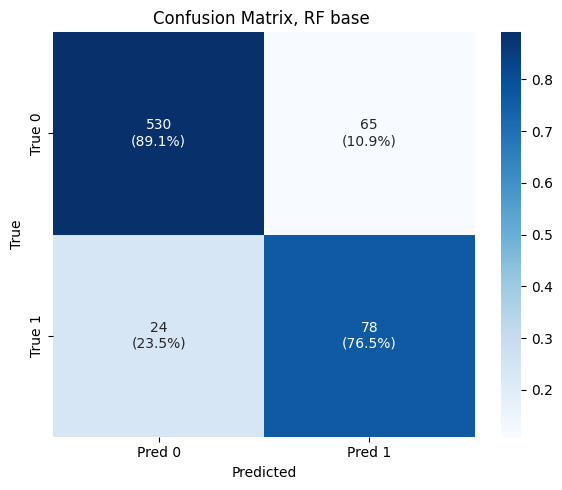

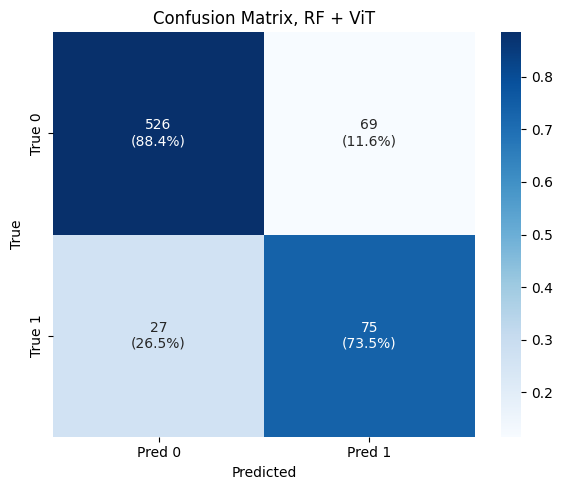

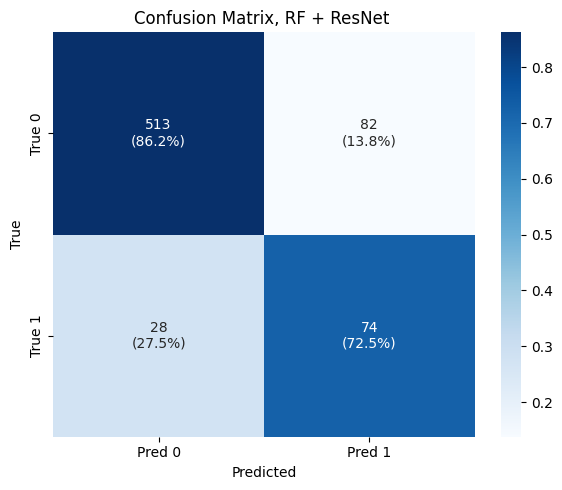

In [30]:
#Evaluate
threshold = 0.5
#BASE
prob_base = rf_base.predict_proba(X_test_base)[:, 1]
pred_base = (prob_base >= threshold).astype(int)

print("\nRF BASE:")
print("AUC:", roc_auc_score(y_test, prob_base))
print("Accuracy:", accuracy_score(y_test, pred_base))
print("Precision:", precision_score(y_test, pred_base, zero_division=0))
print("Recall:", recall_score(y_test, pred_base, zero_division=0))
print("F1:", f1_score(y_test, pred_base, zero_division=0))

cm_base = confusion_matrix(y_test, pred_base, labels=[0, 1])

#VIT
prob_vit  = rf_vit.predict_proba(X_test_vit)[:, 1]
pred_vit = (prob_vit >= threshold).astype(int)

print("\nRF + VIT:")
print("AUC:", roc_auc_score(y_test, prob_vit))
print("Accuracy:", accuracy_score(y_test, pred_vit))
print("Precision:", precision_score(y_test, pred_vit, zero_division=0))
print("Recall:", recall_score(y_test, pred_vit, zero_division=0))
print("F1:", f1_score(y_test, pred_vit, zero_division=0))

cm_vit = confusion_matrix(y_test, pred_vit, labels=[0, 1])

#RESNET
prob_res  = rf_res.predict_proba(X_test_res)[:, 1]
pred_res = (prob_res >= threshold).astype(int)

print("\nRF + RESNET:")
print("AUC:", roc_auc_score(y_test, prob_res))
print("Accuracy:", accuracy_score(y_test, pred_res))
print("Precision:", precision_score(y_test, pred_res, zero_division=0))
print("Recall:", recall_score(y_test, pred_res, zero_division=0))
print("F1:", f1_score(y_test, pred_res, zero_division=0))

cm_res = confusion_matrix(y_test, pred_res, labels=[0, 1])

plot_cm_percent(cm_base, "Confusion Matrix, RF base ")
plot_cm_percent(cm_vit,  "Confusion Matrix, RF + ViT")
plot_cm_percent(cm_res,  "Confusion Matrix, RF + ResNet ")

In [31]:
rf_vit.named_steps["rf"].feature_importances_

array([0.2640913 , 0.14448801, 0.02353421, 0.01894393, 0.01911155,
       0.06691344, 0.02512281, 0.01819241, 0.01877726, 0.01565366,
       0.01646734, 0.0153155 , 0.01606222, 0.01430109, 0.02158538,
       0.01857754, 0.01469985, 0.01582751, 0.01313589, 0.01371163,
       0.01888465, 0.01581975, 0.01214173, 0.01302316, 0.01388682,
       0.01603922, 0.13569213])

In [32]:
rf_res.named_steps["rf"].feature_importances_

array([0.21789466, 0.13833999, 0.02312665, 0.01808598, 0.0187022 ,
       0.05966937, 0.02454183, 0.01762498, 0.01693163, 0.01385295,
       0.0163428 , 0.01354401, 0.01556977, 0.01367004, 0.01843235,
       0.01767301, 0.01484367, 0.01430223, 0.01271217, 0.01294464,
       0.01950909, 0.01464584, 0.01111114, 0.01255073, 0.01278972,
       0.01448026, 0.2161083 ])

### Select features for RF

AUC: 0.8671774592189816
Accuracy: 0.8134863701578192
Precision: 0.41954022988505746
Recall: 0.7156862745098039
F1: 0.5289855072463768


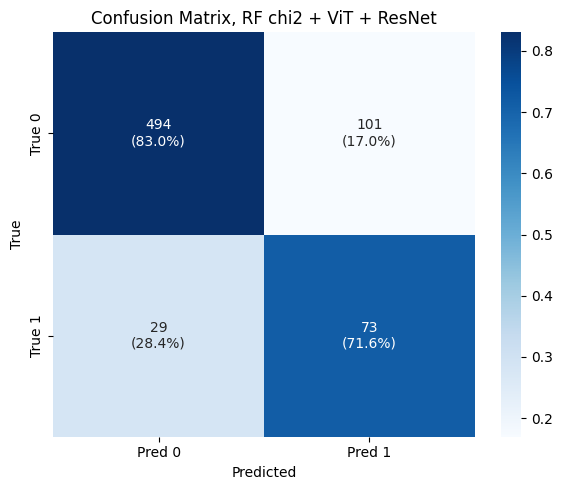

In [33]:
#Select features

CHI2_COL = "CHI2NU"
#"resnet_prob_1"
cols_chi2_probs = [CHI2_COL, "vit_prob_1", ]

X_train_chi2_probs = df_train[cols_chi2_probs]
X_test_chi2_probs  = df_test[cols_chi2_probs]

rf_chi2_probs = make_rf_pipeline(SEED)
rf_chi2_probs.fit(X_train_chi2_probs, y_train)

prob_chi2_probs = rf_chi2_probs.predict_proba(X_test_chi2_probs)[:, 1]
pred_chi2_probs = (prob_chi2_probs >= threshold).astype(int)


print("AUC:", roc_auc_score(y_test, prob_chi2_probs))
print("Accuracy:", accuracy_score(y_test, pred_chi2_probs))
print("Precision:", precision_score(y_test, pred_chi2_probs, zero_division=0))
print("Recall:", recall_score(y_test, pred_chi2_probs, zero_division=0))
print("F1:", f1_score(y_test, pred_chi2_probs, zero_division=0))

cm_chi2_probs = confusion_matrix(y_test, pred_chi2_probs, labels=[0, 1])
plot_cm_percent(cm_chi2_probs, "Confusion Matrix, RF chi2 + ViT + ResNet")

### Colums correlation

In [34]:
cols_corr = ["CHI2NU", "vit_prob_1", "resnet_prob_1"]

for c in cols_corr:
    if c not in df_train.columns:
        raise KeyError(f"Coluna não encontrada: {c}")

print("\nCORRELATION (TRAIN):")
corr_matrix = df_train[cols_corr].corr(method="pearson")
print(corr_matrix)



CORRELATION (TRAIN):
                 CHI2NU  vit_prob_1  resnet_prob_1
CHI2NU         1.000000    0.120846       0.142430
vit_prob_1     0.120846    1.000000       0.661367
resnet_prob_1  0.142430    0.661367       1.000000


### Chatgpt idea

df_test_ens shape: (697, 7)
Missing vit_prob_1: 0.0
Missing resnet_prob_1: 0.0


,object_id,label,rf_base_prob_1,rf_vit_prob_1,rf_resnet_prob_1,vit_prob_1,resnet_prob_1
0,DR4_3_STRIPE82-0141_0008562,0,0.100083,0.070967,0.086883,0.158799,0.121713
1,DR4_3_STRIPE82-0141_0006722,0,0.243083,0.285750,0.330167,0.326934,0.663340
2,DR4_3_STRIPE82-0141_0009758,0,0.051667,0.082217,0.037217,0.281440,0.218267
3,DR4_3_STRIPE82-0141_0010582,0,0.035967,0.046917,0.018500,0.265255,0.142780
4,DR4_3_STRIPE82-0141_0009081,0,0.134833,0.156833,0.116417,0.482986,0.461606



===== WeightedAvg (RF_base vs ResNetDL) alpha=0.50 =====
AUC: 0.8959301367605866
Accuracy: 0.8235294117647058
Precision: 0.4393063583815029
Recall: 0.7450980392156863
F1: 0.5527272727272727


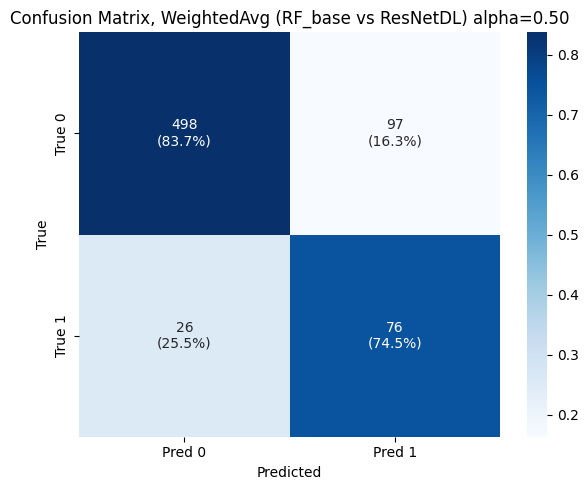


===== WeightedAvg (RF_base+ViTdl+ResNetdl) w=0.33,0.33,0.33 =====
AUC: 0.8834074806393145
Accuracy: 0.8249641319942611
Precision: 0.44047619047619047
Recall: 0.7254901960784313
F1: 0.5481481481481482


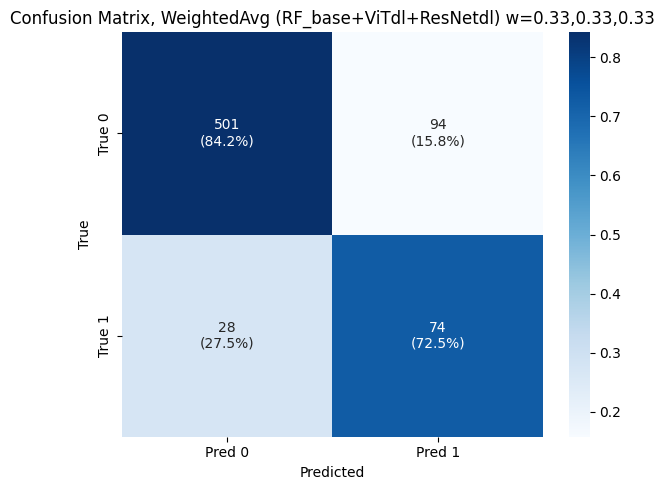


Logistic Regression Weights (STACKING 1):
rf_base_prob_1: 8.4966
vit_prob_1: -1.2978
resnet_prob_1: -1.7209
intercept: -2.5311313562203805

===== STACKING(LogReg) [RF_base, ViT_DL, ResNet_DL] =====
AUC: 0.9463008732904927
Accuracy: 0.8794835007173601
Precision: 0.5608108108108109
Recall: 0.8137254901960784
F1: 0.664


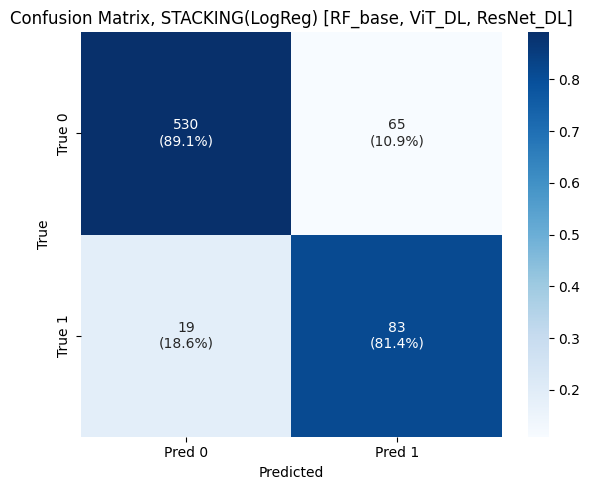


Logistic Regression Weights (STACKING 2):
rf_base_prob_1: 5.2806
rf_vit_prob_1: 3.2002
rf_resnet_prob_1: 2.2414
vit_prob_1: -2.2842
resnet_prob_1: -2.9801
intercept: -2.418508352965961

===== STACKING(LogReg) [RF_base, RF_vit, RF_res, ViT_DL, ResNet_DL] =====
AUC: 0.9441423628274839
Accuracy: 0.8751793400286944
Precision: 0.5503355704697986
Recall: 0.803921568627451
F1: 0.6533864541832669


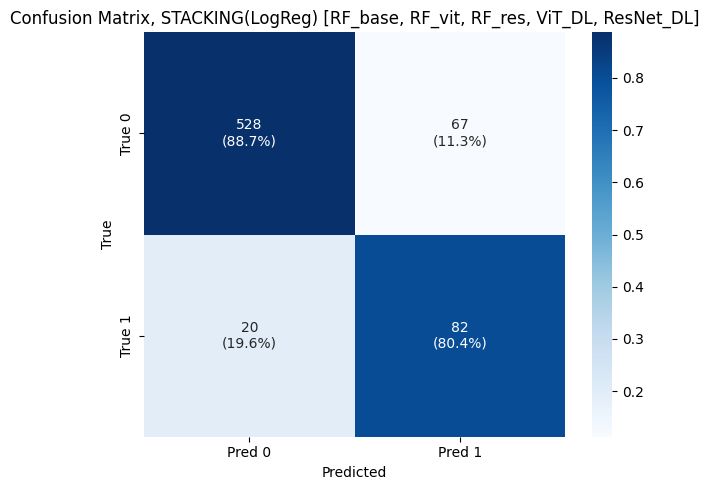

array([[528,  67],
       [ 20,  82]])

In [35]:
# =========================================================
# ENSEMBLE FINAL: Média ponderada + Stacking
# (cole este bloco no FINAL do notebook)
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression

# ---------- helper: avaliar ----------
def eval_probs(y_true, prob, name="MODEL", thr=0.5):
    prob = np.asarray(prob, dtype=float)
    pred = (prob >= thr).astype(int)

    print(f"\n===== {name} =====")
    try:
        print("AUC:", roc_auc_score(y_true, prob))
    except Exception as e:
        print("AUC: erro:", e)

    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall:", recall_score(y_true, pred, zero_division=0))
    print("F1:", f1_score(y_true, pred, zero_division=0))

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    plot_cm_percent(cm, f"Confusion Matrix, {name}")
    return cm

# =========================================================
# 1) Criar tabelas de PROB no nível object_id para o TEST
# =========================================================

# A) probs do RF (já estão alinhadas com df_test pois vieram de X_test_*)
# vamos salvar no df_test para usar em ensembles
df_test_ens = df_test[["object_id", "label"]].copy()
df_test_ens["rf_base_prob_1"]   = prob_base
df_test_ens["rf_vit_prob_1"]    = prob_vit
df_test_ens["rf_resnet_prob_1"] = prob_res

# B) probs do DL (ViT e ResNet) agregadas por object_id
# você já tem df_vit_test_agg e df_res_test_agg
# que são médias por object_id extraídas do loader_paths
df_test_ens = (
    df_test_ens
    .merge(df_vit_test_agg, on="object_id", how="left")   # vit_prob_1
    .merge(df_res_test_agg, on="object_id", how="left")   # resnet_prob_1
)

# checagens básicas
print("df_test_ens shape:", df_test_ens.shape)
print("Missing vit_prob_1:", df_test_ens["vit_prob_1"].isna().mean())
print("Missing resnet_prob_1:", df_test_ens["resnet_prob_1"].isna().mean())
display(df_test_ens.head())

# se tiver NaN (por falta de match), preenche com a média do próprio test
for c in ["vit_prob_1", "resnet_prob_1", "rf_base_prob_1", "rf_vit_prob_1", "rf_resnet_prob_1"]:
    if c in df_test_ens.columns:
        df_test_ens[c] = df_test_ens[c].astype(float)
        if df_test_ens[c].isna().any():
            df_test_ens[c] = df_test_ens[c].fillna(df_test_ens[c].mean())

y_true_test = df_test_ens["label"].values

# =========================================================
# 2) MÉDIA PONDERADA (sem treino, só validação de alpha/betas)
# =========================================================

# Você pode combinar:
# - RF base + ResNet DL
# - RF+ResNet (tabular com prob) + ResNet DL
# - ou 3 modelos (RF base, ViT DL, ResNet DL)

# Exemplo 2.1: RF base + ResNet (DL)
alpha = 0.5  # ajuste depois usando VAL
prob_ens_2 = alpha * df_test_ens["rf_base_prob_1"].values + (1 - alpha) * df_test_ens["resnet_prob_1"].values
eval_probs(y_true_test, prob_ens_2, name=f"WeightedAvg (RF_base vs ResNetDL) alpha={alpha:.2f}")

# Exemplo 2.2: 3 modelos (RF base + ViT DL + ResNet DL)
w1, w2, w3 = 1/3, 1/3, 1/3
prob_ens_3 = (
    w1 * df_test_ens["rf_base_prob_1"].values +
    w2 * df_test_ens["vit_prob_1"].values +
    w3 * df_test_ens["resnet_prob_1"].values
)
eval_probs(y_true_test, prob_ens_3, name=f"WeightedAvg (RF_base+ViTdl+ResNetdl) w={w1:.2f},{w2:.2f},{w3:.2f}")

# =========================================================
# 3) STACKING (treina meta-modelo no VAL, aplica no TEST)
# =========================================================
# Regra de ouro: o meta-modelo deve ser treinado em VAL (ou OOF), nunca no TEST.

# Precisamos montar df_val_ens também (igual ao test)
df_val_ens = df_val[["object_id", "label"]].copy()

# Para o VAL, você já tem:
# - df_vit_val_agg (vit_prob_1)
# - df_res_val_agg (resnet_prob_1)
# E você pode gerar probs do RF no val de duas formas:
#   a) treinar RF no train e prever no val
#   b) ou já ter feito isso antes (recomendado)
#
# Vou fazer (a) aqui para ficar plug-and-play:

# ---------- RF treinado no train e prevendo no val ----------
# (usando as mesmas features dos seus RFs anteriores)

# BASE features
prob_base_val = rf_base.predict_proba(df_val[base_cols])[:, 1]

# RF + VIT feature (tabular + vit_prob_1)
prob_vit_val  = rf_vit.predict_proba(df_val[vit_cols])[:, 1]

# RF + RESNET feature (tabular + resnet_prob_1)
prob_res_val  = rf_res.predict_proba(df_val[res_cols])[:, 1]

df_val_ens["rf_base_prob_1"]   = prob_base_val
df_val_ens["rf_vit_prob_1"]    = prob_vit_val
df_val_ens["rf_resnet_prob_1"] = prob_res_val

df_val_ens = (
    df_val_ens
    .merge(df_vit_val_agg, on="object_id", how="left")
    .merge(df_res_val_agg, on="object_id", how="left")
)

for c in ["vit_prob_1", "resnet_prob_1", "rf_base_prob_1", "rf_vit_prob_1", "rf_resnet_prob_1"]:
    df_val_ens[c] = df_val_ens[c].astype(float)
    if df_val_ens[c].isna().any():
        df_val_ens[c] = df_val_ens[c].fillna(df_val_ens[c].mean())

y_true_val = df_val_ens["label"].values

# ---------- escolher quais modelos entram no stacking ----------
# opção boa e simples: [RF_base, ViT_DL, ResNet_DL]
X_meta_val = df_val_ens[["rf_base_prob_1", "vit_prob_1", "resnet_prob_1"]].values
X_meta_test = df_test_ens[["rf_base_prob_1", "vit_prob_1", "resnet_prob_1"]].values

meta = LogisticRegression(max_iter=2000, class_weight="balanced")
meta.fit(X_meta_val, y_true_val)
print("\nLogistic Regression Weights (STACKING 1):")

feature_names = ["rf_base_prob_1", "vit_prob_1", "resnet_prob_1"]

for name, weight in zip(feature_names, meta.coef_[0]):
    print(f"{name}: {weight:.4f}")

print("intercept:", meta.intercept_[0])

prob_stack = meta.predict_proba(X_meta_test)[:, 1]
eval_probs(y_true_test, prob_stack, name="STACKING(LogReg) [RF_base, ViT_DL, ResNet_DL]")

# opcional: stacking com os 5 (inclui RF_vit e RF_resnet também)
X_meta_val2 = df_val_ens[["rf_base_prob_1", "rf_vit_prob_1", "rf_resnet_prob_1", "vit_prob_1", "resnet_prob_1"]].values
X_meta_test2 = df_test_ens[["rf_base_prob_1", "rf_vit_prob_1", "rf_resnet_prob_1", "vit_prob_1", "resnet_prob_1"]].values

meta2 = LogisticRegression(max_iter=3000, class_weight="balanced")
meta2.fit(X_meta_val2, y_true_val)
print("\nLogistic Regression Weights (STACKING 2):")

feature_names2 = [
    "rf_base_prob_1",
    "rf_vit_prob_1",
    "rf_resnet_prob_1",
    "vit_prob_1",
    "resnet_prob_1"
]

for name, weight in zip(feature_names2, meta2.coef_[0]):
    print(f"{name}: {weight:.4f}")

print("intercept:", meta2.intercept_[0])

prob_stack2 = meta2.predict_proba(X_meta_test2)[:, 1]
eval_probs(y_true_test, prob_stack2, name="STACKING(LogReg) [RF_base, RF_vit, RF_res, ViT_DL, ResNet_DL]")